In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!git clone https://github.com/eya-bouhmida/Multimodal-RAG-From-Scratch.git

import os, shutil
os.chdir('/content/Multimodal-RAG-From-Scratch')

if os.path.exists('data'):
    if os.path.islink('data'):
        os.unlink('data')
    else:
        shutil.rmtree('data')

os.symlink(
    '/content/drive/MyDrive/multimodal-rag-project/data',
    '/content/Multimodal-RAG-From-Scratch/data'
)
print(os.listdir('data/raw/'))

Cloning into 'Multimodal-RAG-From-Scratch'...
remote: Enumerating objects: 72, done.
remote: Counting objects: 100% (72/72), done.
remote: Compressing objects: 100% (60/60), done.
remote: Total 72 (delta 34), reused 21 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (72/72), 50.82 KiB | 426.00 KiB/s, done.
Resolving deltas: 100% (34/34), done.
['pubmed_multimodal', 'has_fr', 'who_en']


In [ ]:
!pip install sentence-transformers qdrant-client rank-bm25 groq -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.2/396.2 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 11.1 MB/s eta 0:00:00


In [ ]:
import json
import numpy as np
from sentence_transformers import SentenceTransformer, CrossEncoder
from qdrant_client import QdrantClient
from rank_bm25 import BM25Okapi
from groq import Groq

In [ ]:
QDRANT_URL = "https://a52409e3-d81f-4182-a9f5-a23b1511daef.australia-southeast1-0.gcp.cloud.qdrant.io"
COLLECTION_NAME = "medlens"
import os
QDRANT_API_KEY = os.getenv("QDRANT_API_KEY")
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

client = QdrantClient(url=QDRANT_URL, api_key=QDRANT_API_KEY)

groq_client = Groq(api_key=GROQ_API_KEY)

print(f"✅ Connecté!")
print(f"Text chunks: {client.count('medlens').count}")
print(f"Image chunks: {client.count('medlens_images').count}")

✅ Connecté!
Text chunks: 38214
Image chunks: 200


In [ ]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'

embedding_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2', device=device)
reranker = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')
print(f"✅ Modèles chargés sur {device}!")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

✅ Modèles chargés sur cuda!


In [ ]:
print("⏳ Loading BM25...")

all_chunks = []
results, offset = client.scroll(
    collection_name=COLLECTION_NAME,
    limit=5000,
    offset=None,
    with_payload=True,
    with_vectors=False
)
all_chunks.extend(results)

tokenized_chunks = [chunk.payload['text'].lower().split() for chunk in all_chunks]
bm25 = BM25Okapi(tokenized_chunks)
print(f"✅ BM25 ready with {len(all_chunks)} chunks!")

⏳ Loading BM25...
✅ BM25 ready with 5000 chunks!


In [ ]:
def dense_search(query, top_k=20):
    query_vector = embedding_model.encode(query).tolist()
    results = client.query_points(
        collection_name=COLLECTION_NAME,
        query=query_vector,
        limit=top_k,
        with_payload=True
    ).points
    return results

def bm25_search(query, top_k=20):
    tokenized_query = query.lower().split()
    scores = bm25.get_scores(tokenized_query)
    top_indices = np.argsort(scores)[::-1][:top_k]
    return [{"id": all_chunks[idx].id, "score": scores[idx], "payload": all_chunks[idx].payload} for idx in top_indices]

def reciprocal_rank_fusion(dense_results, bm25_results, k=60):
    scores = {}
    for rank, result in enumerate(dense_results):
        doc_id = result.id
        if doc_id not in scores:
            scores[doc_id] = {"score": 0, "payload": result.payload}
        scores[doc_id]["score"] += 1 / (k + rank + 1)
    for rank, result in enumerate(bm25_results):
        doc_id = result["id"]
        if doc_id not in scores:
            scores[doc_id] = {"score": 0, "payload": result["payload"]}
        scores[doc_id]["score"] += 1 / (k + rank + 1)
    return sorted(scores.items(), key=lambda x: x[1]["score"], reverse=True)[:20]

def rerank(query, fused_results, top_k=8):
    pairs = [[query, result[1]["payload"]["text"]] for result in fused_results]
    scores = reranker.predict(pairs)
    ranked = sorted(zip(scores, fused_results), key=lambda x: x[0], reverse=True)
    return ranked[:top_k]

def hybrid_search(query, top_k=8):
    dense_results = dense_search(query, top_k=20)
    bm25_results = bm25_search(query, top_k=20)
    fused = reciprocal_rank_fusion(dense_results, bm25_results)
    return rerank(query, fused, top_k=top_k)

In [ ]:
def image_search(query, top_k=3):
    query_vector = embedding_model.encode(query).tolist()
    results = client.query_points(
        collection_name="medlens_images",
        query=query_vector,
        limit=top_k,
        with_payload=True
    ).points
    return results

In [ ]:
def build_multimodal_prompt(query, text_chunks, image_results):
    context = ""
    sources = []

    context += "=== MEDICAL DOCUMENTS ===\n"
    for i, (score, result) in enumerate(text_chunks):
        payload = result[1]["payload"]
        context += f"\n--- Document {i+1} ---\n"
        context += f"Source: {payload['filename']} (Page {payload['page_num']})\n"
        context += f"{payload['text']}\n"
        sources.append(f"{payload['filename']} p.{payload['page_num']}")

    if image_results:
        context += "\n=== MEDICAL FIGURES AND IMAGES ===\n"
        for i, img in enumerate(image_results):
            context += f"\n--- Figure {i+1} ---\n"
            context += f"Image: {img.payload['filename']}\n"
            context += f"Description: {img.payload['text']}\n"
            sources.append(f"Figure: {img.payload['filename']}")

    prompt = f"""You are MedLens, an expert bilingual medical assistant (French/English).

ABSOLUTE RULES:
1. Answer ONLY using information from the documents provided below.
2. Do NOT use your own general knowledge under any circumstances.
3. Every statement must be directly traceable to the provided documents.
4. If the information is not in the documents, say exactly: "I cannot find this information in the available documents."
5. After each important statement, cite the source in parentheses (filename and page number).
6. Always respond in the same language as the question.
7. Be precise, clear, and helpful — you are helping non-medical people understand health information.

MEDICAL CONTEXT:
{context}

QUESTION: {query}

DETAILED CITED RESPONSE:"""

    return prompt, sources

In [ ]:
def generate_response(query):
    # Retrieval with top_k=8
    text_chunks = hybrid_search(query, top_k=8)
    image_results = image_search(query, top_k=3)
    prompt, sources = build_multimodal_prompt(query, text_chunks, image_results)

    response = groq_client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=1200,
        temperature=0.05  # ✅ lower temperature = more faithful
    )

    answer = response.choices[0].message.content

    return {
        "question": query,
        "answer": answer,
        "sources": sources,
        "text_chunks": len(text_chunks),
        "images_used": len(image_results)
    }

In [ ]:
from IPython.display import display, Image as IPImage

def generate_response_with_images(query):
    text_chunks = hybrid_search(query, top_k=8)
    image_results = image_search(query, top_k=3)
    prompt, sources = build_multimodal_prompt(query, text_chunks, image_results)

    response = groq_client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=1200,
        temperature=0.05
    )

    answer = response.choices[0].message.content

    print(f"❓ Question: {query}")
    print(f"\n🤖 MedLens:\n{answer}")
    print(f"\n📄 Sources: {sources[:5]}")

    if image_results:
        print(f"\n🖼️ Relevant medical images ({len(image_results)}):")
        for i, img in enumerate(image_results):
            img_path = img.payload.get('image_path', '')
            caption = img.payload.get('text', '')
            print(f"\n--- Figure {i+1} ---")
            print(f"📝 {caption[:150]}...")
            if os.path.exists(img_path):
                display(IPImage(filename=img_path, width=400))
            else:
                print(f"⚠️ Image not found locally")

❓ Question: What are the symptoms of diabetes?

🤖 MedLens:
Les symptômes du diabète peuvent varier d'une personne à l'autre, mais certains sont plus courants que d'autres. (diabete3.pdf, Page 10)

Les signes et symptômes avancés courants de l'hypoglycémie incluent :

- Transpiration
- Tremblements
- Pâleur
- Faim
- Sensation de légèreté/vertige/maux de tête
- Changement d'humeur

Cependant, avant le diagnostic, l’hyperglycémie incontrôlée est responsable des symptômes les plus fréquemment observés, qui incluent :

- Fatigue
- Soif
- Amaigrissement
- Polyurie

Il est important de noter que ces symptômes peuvent ne pas être présents chez toutes les personnes atteintes de diabète, et que certains peuvent avoir des symptômes plus graves ou plus rares. (diabete3.pdf, Page 10)

De plus, selon le document diabeteeng4.pdf (Page 43), les symptômes de l'hyperglycémie peuvent inclure :

- Tired
- Passer plus d'urine
- Soif
- Faim (même si vous mangez)
- Sores ou coupures qui ne guérissent pas rap

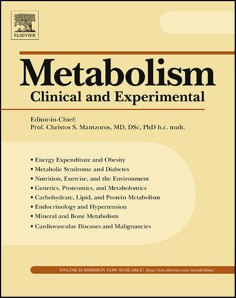


--- Figure 2 ---
📝 This is a **non-medical image** showing a partial list of risk factors categorized into different types. It appears to be a section of a diagram illus...


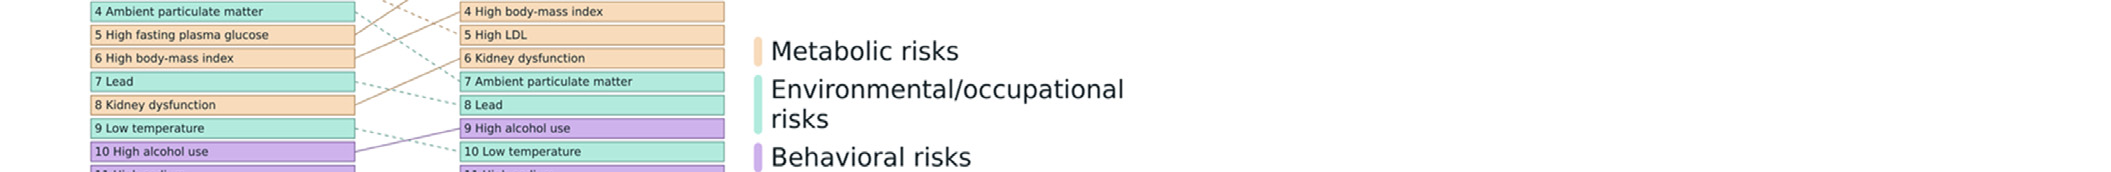


--- Figure 3 ---
📝 This is a medical image, specifically a box-and-whisker plot combined with individual data points.

It shows the age-standardized mortality rate per 1...


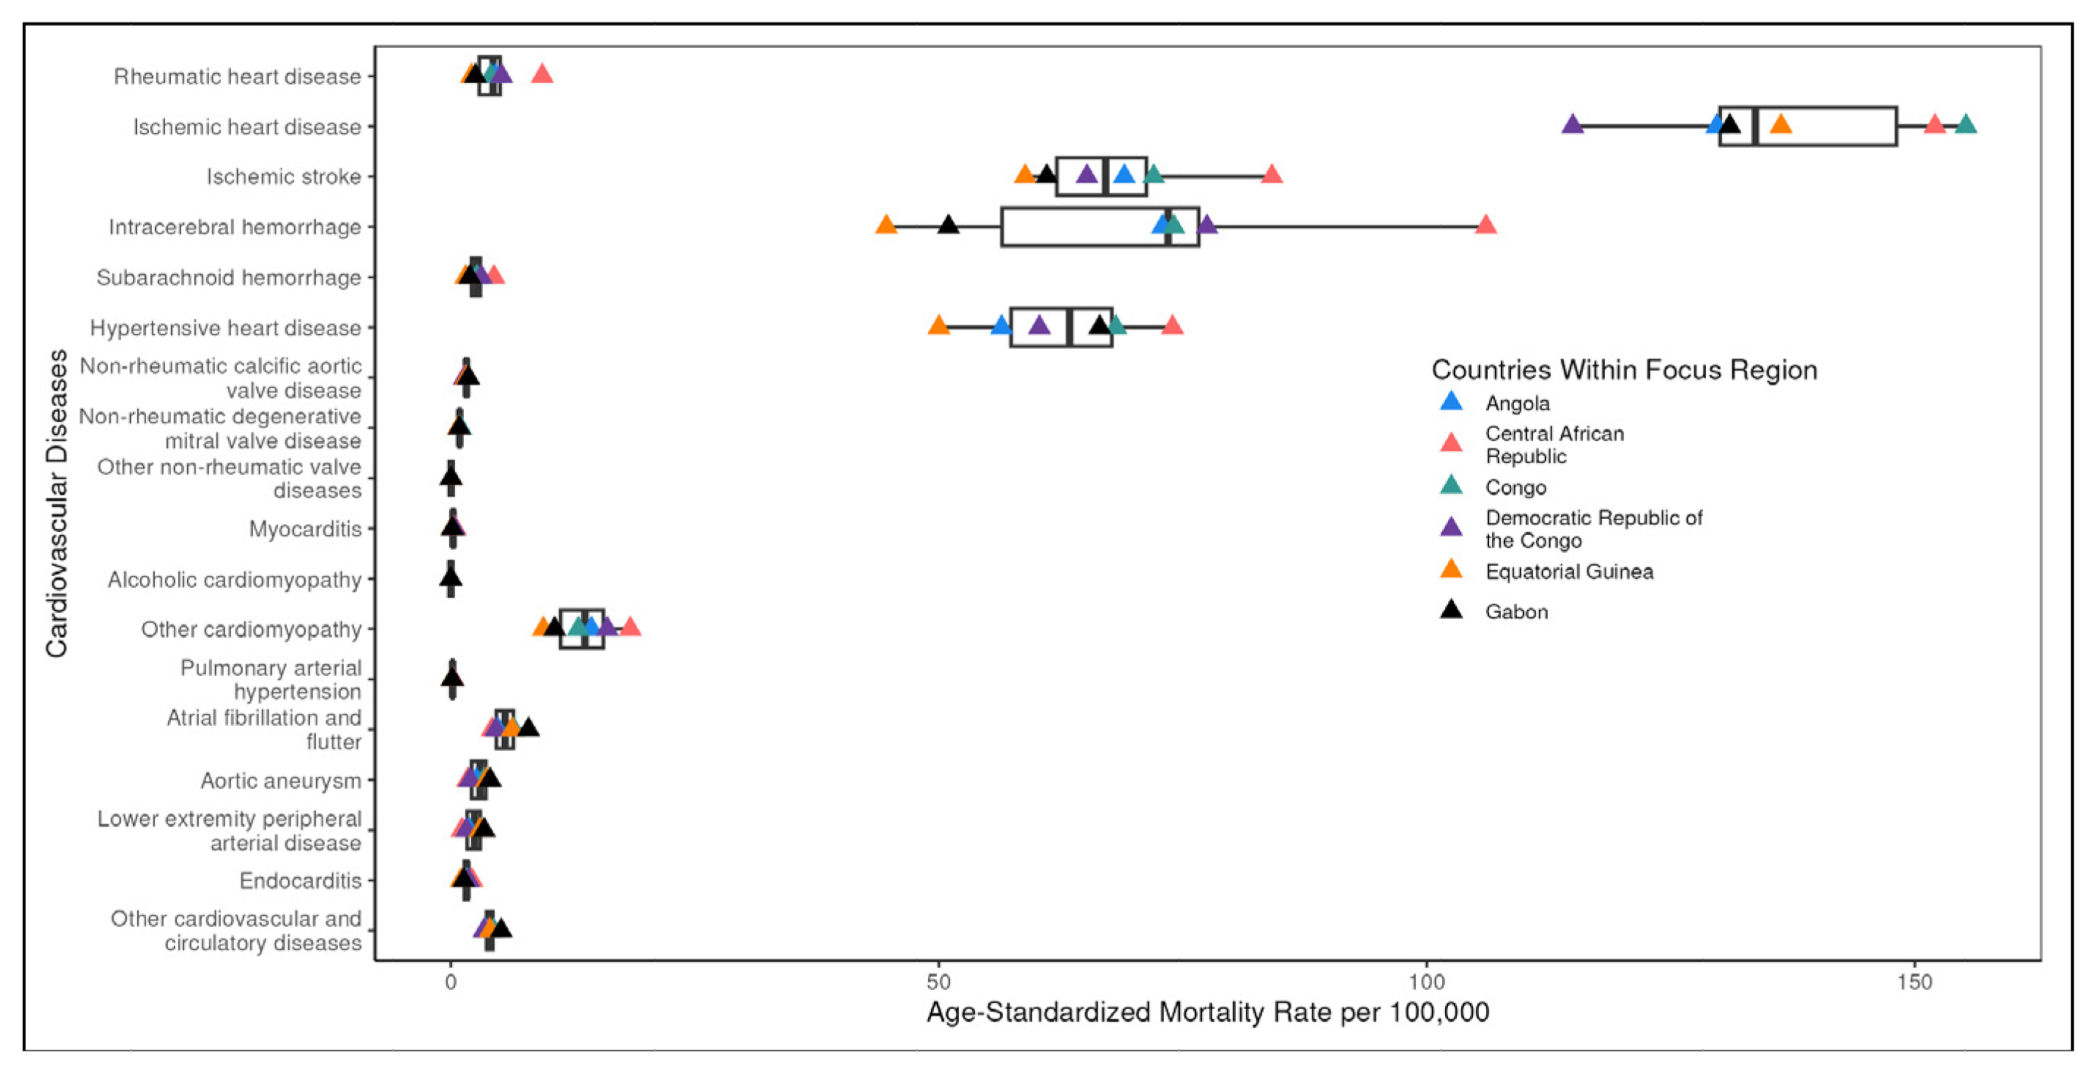

In [ ]:
generate_response_with_images("What are the symptoms of diabetes?")

❓ Question: Quels sont les traitements pour l'hypertension?

🤖 MedLens:
Les traitements pour l'hypertension peuvent varier en fonction de la gravité de la maladie et des facteurs de risque individuels. Selon les documents fournis, voici quelques informations sur les traitements pour l'hypertension :

*   Selon le document 2 (hyper5.pdf, page 3), il est possible de prévenir et de maîtriser l'hypertension par l'adoption de saines habitudes de vie et, au besoin, par les médicaments pour une maîtrise accrue.
*   Le document 4 (hyper9.pdf, page 4) mentionne que la tension artérielle est un des signes vitaux qui reflètent votre état de santé global, et que l'hypertension peut causer de nombreux problèmes, en particulier au cœur, au cerveau et aux reins.
*   Le document 7 (diabete_guidelineeng2.pdf, page 22) décrit un régime de huit semaines qui a permis à certains participants de perdre du poids et d'améliorer leur glycémie et leur tension artérielle.
*   Le document 8 (hyper9.pdf, page 4) m

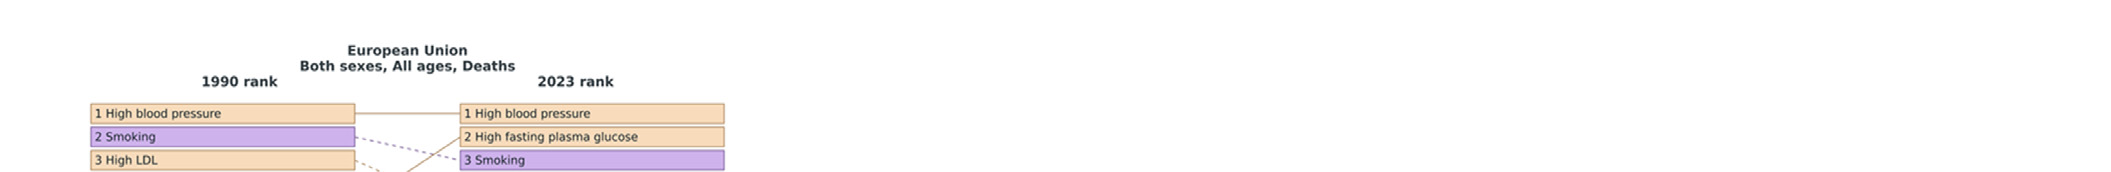


--- Figure 2 ---
📝 This is a **medical journal cover**.

It shows the cover of a journal titled "**Metabolism: Clinical and Experimental**".

The medical information it ...


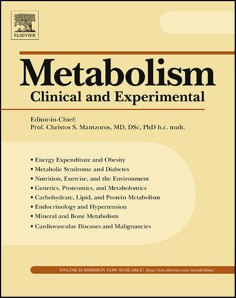


--- Figure 3 ---
📝 This is a medical image, specifically a figure containing two charts (A and B) related to cardiovascular diseases and risk factors.

**A. Bar Chart: A...


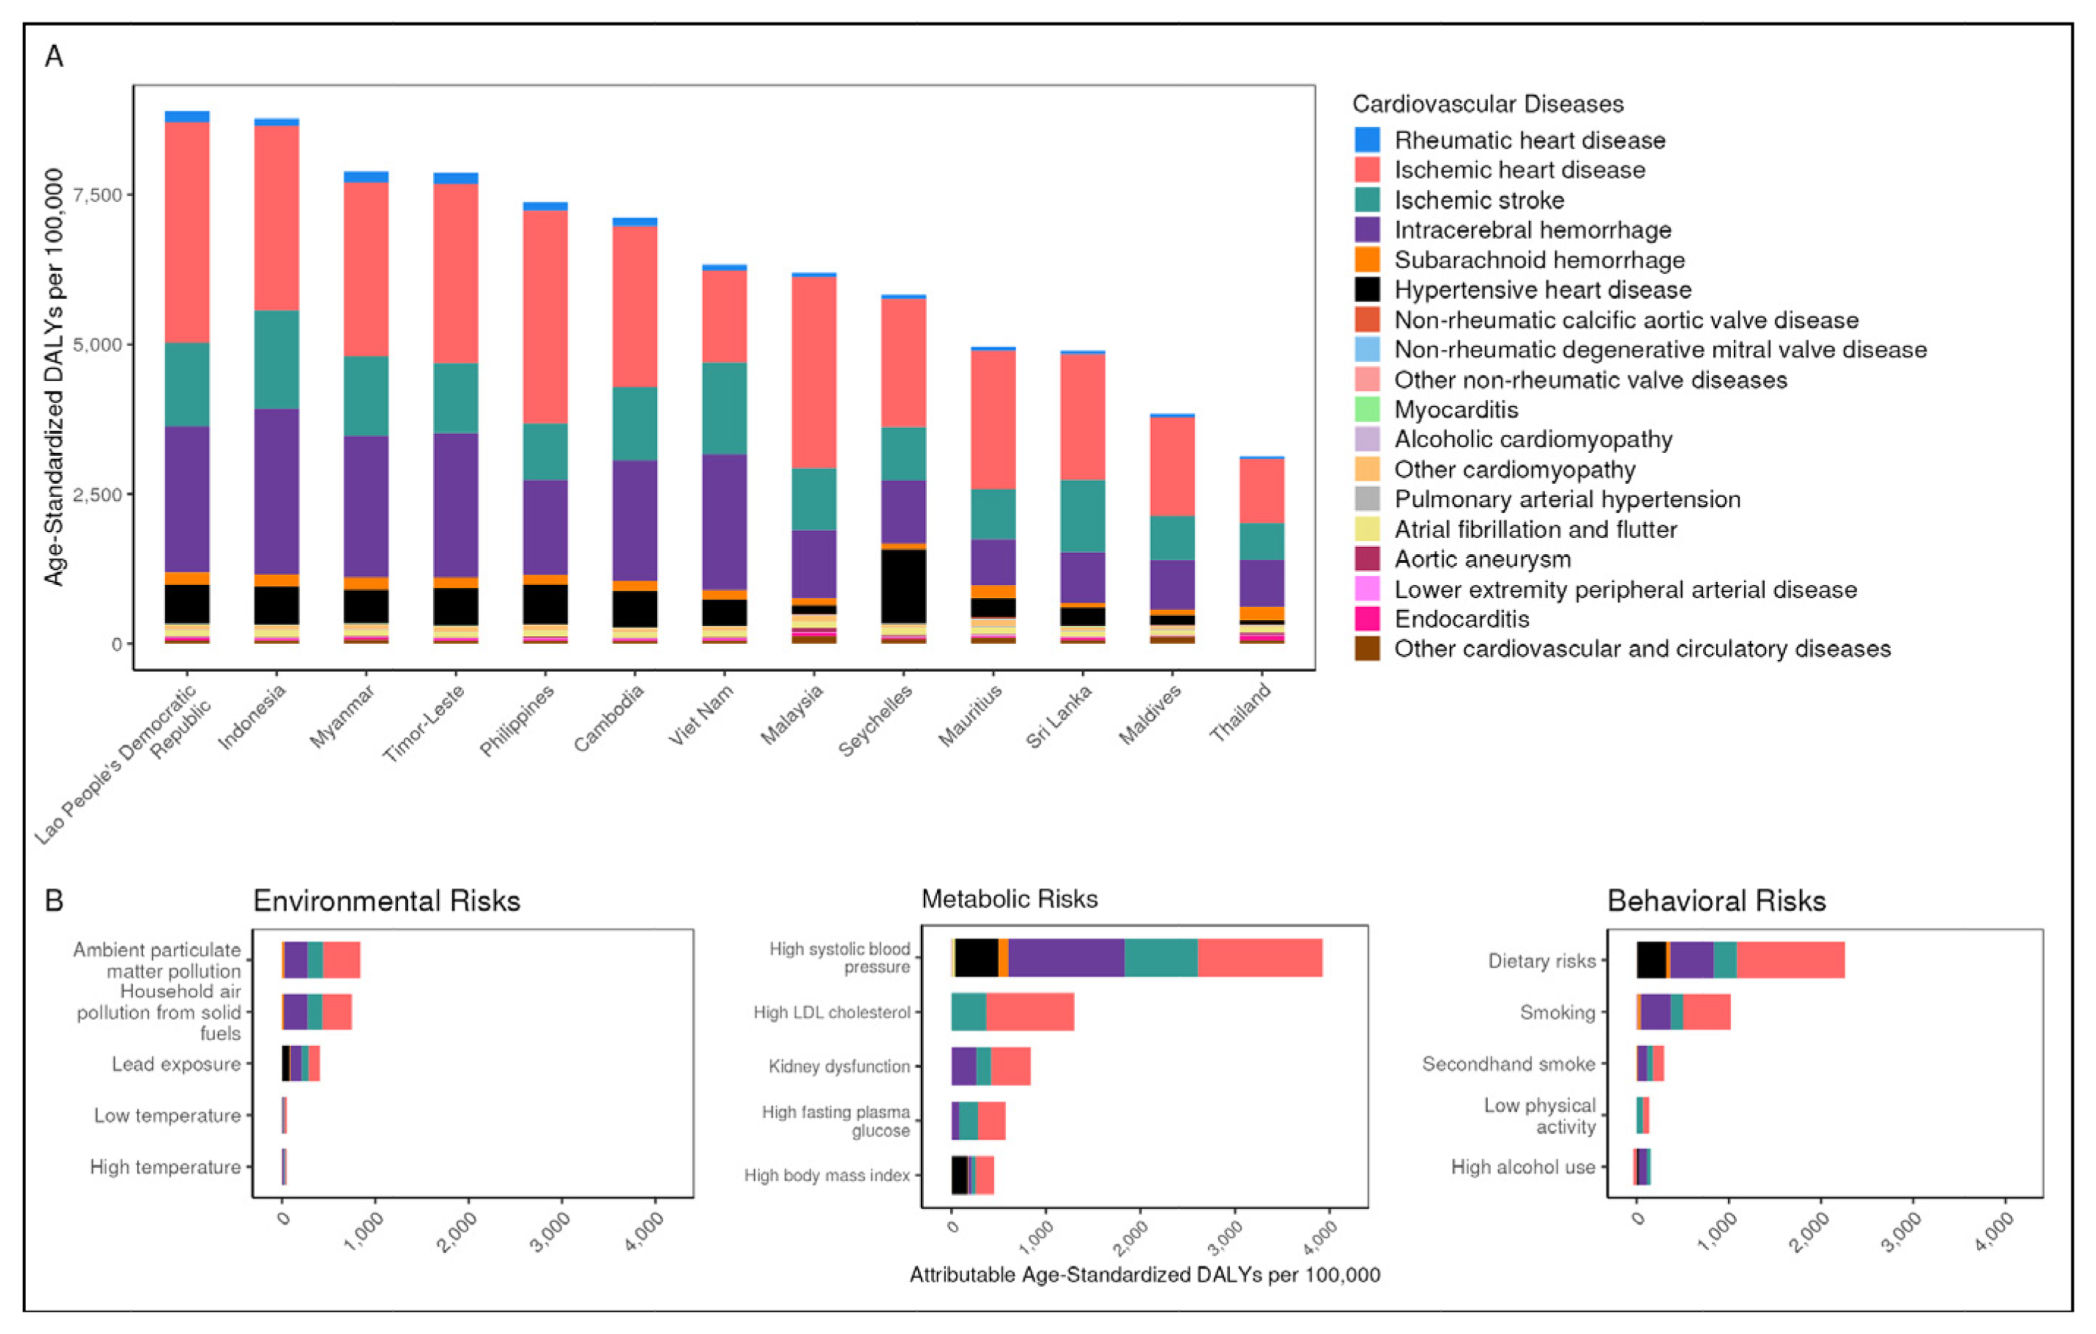

In [ ]:
generate_response_with_images("Quels sont les traitements pour l'hypertension?")

In [ ]:
result = generate_response("What is the recommended treatment for type 2 diabetes?")
print(f"✅ Answer quality check:")
print(f"Text chunks used: {result['text_chunks']}")
print(f"Images used: {result['images_used']}")
print(f"\nAnswer:\n{result['answer']}")
print(f"\nSources: {result['sources']}")

✅ Answer quality check:
Text chunks used: 8
Images used: 3

Answer:
La recommandation de traitement pour le diabète de type 2 est la suivante :

*   La prise en charge non médicamenteuse (HAS) recommande la suivante : 
    *   Prise en charge non médicamenteuse (HAS) recommande la suivante : 
        *   Activité physique et sportive (HAS, 2018) 
        *   Diabète de type 2 : traitement médicamenteux de l’hyperglycémie (SSMG, 2015) 
        *   Études Entred : un dispositif pour améliorer la connaissance de l’état de santé des personnes présentant un diabète en France – Premiers résultats de la troisième édition conduite en métropole en 2019 (Fosse-Edorh, 2022) 
    *   La prise en charge médicamenteuse recommandée est la suivante : 
        *   Metformin (Schlender, 2017) 
        *   Pioglitazone (Schlender, 2017) 
        *   Glimepiride (Schlender, 2017) 
        *   Insuline (Schlender, 2017) 
*   La prise en charge non médicamenteuse recommandée est la suivante : 
    *   Activ